# Bernouli Naive Bayes

In [58]:
import pandas as pd
import matplotlib as plt
import seaborn as sns

# Importing Dataset

In [59]:
df=pd.read_csv("Twitter Sentiment.csv", encoding='latin-1',header=None)

In [60]:
df

,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
...,...,...,...,...,...,...
1599995,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599996,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599997,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599998,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


# Data Preprocessing

In [61]:
df.columns

Index([0, 1, 2, 3, 4, 5], dtype='int64')

In [62]:
df.columns=['target','id','date','flag','user','text']
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1600000 entries, 0 to 1599999
Data columns (total 6 columns):
 #   Column  Non-Null Count    Dtype 
---  ------  --------------    ----- 
 0   target  1600000 non-null  int64 
 1   id      1600000 non-null  int64 
 2   date    1600000 non-null  object
 3   flag    1600000 non-null  object
 4   user    1600000 non-null  object
 5   text    1600000 non-null  object
dtypes: int64(2), object(4)
memory usage: 73.2+ MB


In [63]:
data=df[['target','text']]
data.head()

,target,text
0,0,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,is upset that he can't update his Facebook by ...
2,0,@Kenichan I dived many times for the ball. Man...
3,0,my whole body feels itchy and like its on fire
4,0,"@nationwideclass no, it's not behaving at all...."


In [64]:
data.shape

(1600000, 2)

In [65]:
data=data.sample(100000,random_state=42)

In [66]:
data['target'].unique()

array([0, 4], dtype=int64)

In the data 0 means Negative and 4 means Positive
we can convert this o means negative and 1 means positive

In [67]:
data.isnull().sum()

target    0
text      0
dtype: int64

In [68]:
data['target']=data['target'].replace(4,1)

In [69]:
data['target'].unique()
data['target'].value_counts()

target
1    50057
0    49943
Name: count, dtype: int64

# Cleaning data

In [70]:
import re 
import string
def clean_text(text):
    #lowercase
    text=text.lower()
    #remove punctuation
    text=text.translate(str.maketrans('','',string.punctuation))
    #remove @mention
    text=re.sub(r'@\w+','',text)
    #remove urls
    text=re.sub(r'https?://\S+|www\.\S+','',text)
    #remove extra spaces
    text=re.sub(r'\s+',' ',text)
    return text

data['text']=data['text'].apply(clean_text)

In [71]:
data.head()

,target,text
541200,0,chrishasboobs ahhh i hope your ok
750,0,misstoriblack cool i have no tweet apps for my...
766711,0,tiannachaos i know just family drama its lameh...
285055,0,school email wont open and i have geography st...
705995,0,upper airways problem


# EDA

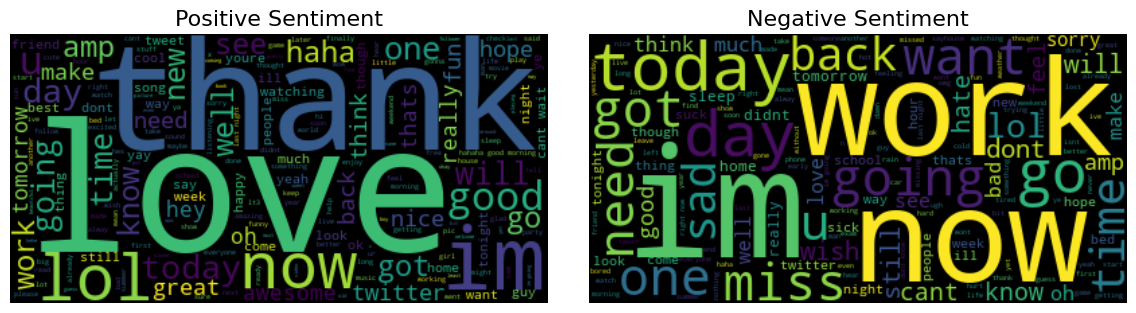

In [72]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
positive_text=data[data['target']==1]['text'].str.cat(sep=' ')
negative_text=data[data['target']==0]['text'].str.cat(sep=' ')
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.imshow(WordCloud().generate(positive_text), interpolation='bilinear')
plt.title('Positive Sentiment', fontsize=16)
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(WordCloud().generate(negative_text), interpolation='bilinear')
plt.title('Negative Sentiment', fontsize=16)
plt.axis('off')

plt.tight_layout(pad=3)
plt.show()


Most common text in the Postive and negative Sentiment

In [73]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score,classification_report,f1_score

In [74]:
X=data['text']
y=data['target']

In [75]:
X=data['text'].astype(str)
X

541200                   chrishasboobs ahhh i hope your ok 
750       misstoriblack cool i have no tweet apps for my...
766711    tiannachaos i know just family drama its lameh...
285055    school email wont open and i have geography st...
705995                               upper airways problem 
                                ...                        
159217    finallytryingto download evernote on my bberry...
298540    kimberly625 amylovesoliver too late guess im b...
839945               on the way to target with mah sistaaa 
732586    hip is worse today moving my leg causes pain o...
429504                   1 more week what to do what to do 
Name: text, Length: 100000, dtype: object

# Spliting the data 

In [76]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)


# Vectorization

In [77]:
vectorizer=CountVectorizer(binary=True)
x_train_vectorized=vectorizer.fit_transform(x_train)
x_test_vectorized=vectorizer.transform(x_test)

# Train Model

In [78]:
model=BernoulliNB()
model.fit(x_train_vectorized,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [79]:
import pickle
pickle.dump(vectorizer, open('bernoullivectorizer.pkl', 'wb'))

In [80]:
pickle.dump(model, open('bernoullimodel.pkl', 'wb'))

# prediction

In [81]:
y_pred=model.predict(x_test_vectorized)

# Model Evaluation

In [82]:
print("Accuracy:",accuracy_score(y_test,y_pred)*100)
print("f1 score:", f1_score(y_test,y_pred)*100)

Accuracy: 76.395
f1 score: 75.68374967808396


In [83]:
print("Classification Report:",classification_report(y_test,y_pred))

Classification Report:               precision    recall  f1-score   support

           0       0.75      0.79      0.77      9995
           1       0.78      0.73      0.76     10005

    accuracy                           0.76     20000
   macro avg       0.76      0.76      0.76     20000
weighted avg       0.76      0.76      0.76     20000



# Confusion Matrix

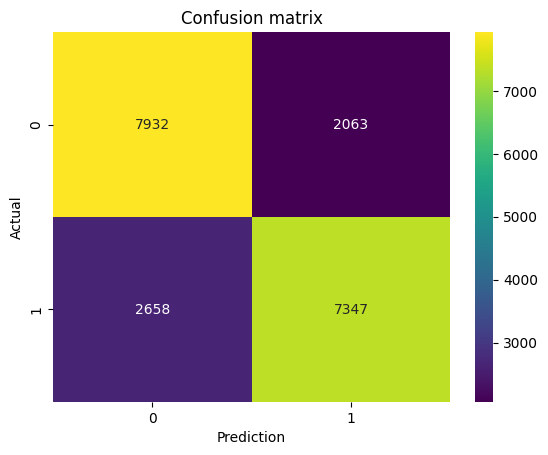

In [84]:
from sklearn.metrics import confusion_matrix

# Fix: confusion_matrix should take (y_true, y_pred), and avoid name clash.
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='viridis')
plt.title('Confusion matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()